In [1]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Load Data from Previous Steps ---
A_basis = np.load('../data/A_basis.npy')
player_names = pd.read_csv('../data/player_names.csv').iloc[:, 0].values
basis_features = pd.read_csv('../data/basis_features.csv').iloc[:, 0].values

print("Data loaded successfully!")
print(f"A_basis shape : {A_basis.shape}")
print(f"Features      : {list(basis_features)}")

Data loaded successfully!
A_basis shape : (1130, 9)
Features      : ['Matches_Batted', 'Runs_Scored', 'Batting_Average', 'Batting_Strike_Rate', 'Wickets_Taken', 'Economy_Rate', 'Bowling_Average', 'Centuries', 'Catches_Taken']


In [3]:
# --- What is Pattern Discovery? ---
# The covariance matrix of player stats tells us
# how stats vary together across all players.
#
# Eigenvalues of the covariance matrix tell us:
#   → LARGE eigenvalue = strong common pattern among players
#   → SMALL eigenvalue = weak or noisy pattern
#
# Eigenvectors tell us:
#   → The DIRECTION of each pattern in feature space
#   → e.g. "batting dominance", "bowling dominance"
#
# This is the mathematical foundation of PCA
# (Principal Component Analysis)

In [4]:
# --- Step 1: Compute Covariance Matrix ---
# np.cov expects features as rows, players as columns
# so we transpose A_basis

C = np.cov(A_basis.T)

print("=" * 50)
print("COVARIANCE MATRIX")
print("=" * 50)
print(f"Shape : {C.shape}")
print(f"\nCovariance Matrix C:")
df_cov = pd.DataFrame(C,
                      index=basis_features,
                      columns=basis_features)
print(df_cov.round(2))

COVARIANCE MATRIX
Shape : (9, 9)

Covariance Matrix C:
                     Matches_Batted  Runs_Scored  Batting_Average  \
Matches_Batted                30.55       553.88            37.58   
Runs_Scored                  553.88     29261.91          2193.94   
Batting_Average               37.58      2193.94           273.25   
Batting_Strike_Rate          117.06      4695.55           585.83   
Wickets_Taken                 13.67      -348.40           -31.05   
Economy_Rate                  -3.13      -332.22           -33.01   
Bowling_Average               -4.47     -1263.51          -110.42   
Centuries                      0.22        19.12             1.37   
Catches_Taken                 12.40       363.76            27.52   

                     Batting_Strike_Rate  Wickets_Taken  Economy_Rate  \
Matches_Batted                    117.06          13.67         -3.13   
Runs_Scored                      4695.55        -348.40       -332.22   
Batting_Average                   5

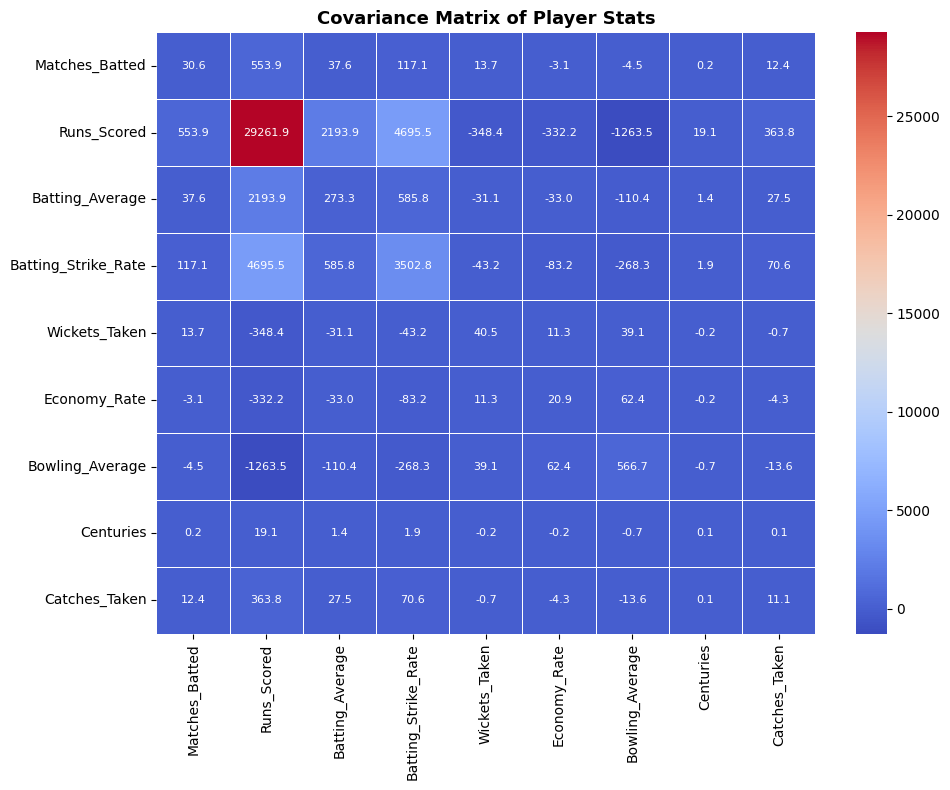

In [5]:
# --- Visualize Covariance Matrix ---
plt.figure(figsize=(10, 8))
sns.heatmap(df_cov, annot=True, fmt='.1f',
            cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Covariance Matrix of Player Stats',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/step8_covariance.png', dpi=150)
plt.show()

In [6]:
# --- Step 2: Compute Eigenvalues and Eigenvectors ---
# np.linalg.eig computes eigenvalues and eigenvectors
# For symmetric matrix (covariance), use eigh for
# guaranteed real, sorted results

eigenvalues, eigenvectors = np.linalg.eig(C)

# Take real parts (covariance matrix should give real values)
eigenvalues  = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort by descending eigenvalue
sort_idx     = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("=" * 50)
print("EIGENVALUES AND EIGENVECTORS")
print("=" * 50)
print(f"\nEigenvalues (sorted descending):")
for i, val in enumerate(eigenvalues):
    print(f"  λ{i+1} = {val:.4f}")

print(f"\nEigenvector Matrix shape : {eigenvectors.shape}")
print(f"(Each column is one eigenvector)")

EIGENVALUES AND EIGENVECTORS

Eigenvalues (sorted descending):
  λ1 = 30341.4893
  λ2 = 2689.6750
  λ3 = 516.3464
  λ4 = 89.5624
  λ5 = 47.3658
  λ6 = 12.3553
  λ7 = 7.5298
  λ8 = 3.4394
  λ9 = 0.0563

Eigenvector Matrix shape : (9, 9)
(Each column is one eigenvector)


In [7]:
# --- Step 3: Variance Explained ---
# Each eigenvalue tells us how much variance
# (information) that direction captures

total_variance = np.sum(eigenvalues)
variance_explained = eigenvalues / total_variance * 100
cumulative_variance = np.cumsum(variance_explained)

print("=" * 50)
print("VARIANCE EXPLAINED BY EACH EIGENVALUE")
print("=" * 50)
print(f"\n{'Component':<12} {'Eigenvalue':>12} {'Variance %':>12} {'Cumulative %':>14}")
print("-" * 52)
for i, (val, var, cum) in enumerate(zip(eigenvalues,
                                         variance_explained,
                                         cumulative_variance)):
    marker = " ← 80% threshold" if abs(cum - 80) < var else ""
    print(f"  PC{i+1:<8} {val:>12.4f} {var:>11.2f}% {cum:>13.2f}%{marker}")

VARIANCE EXPLAINED BY EACH EIGENVALUE

Component      Eigenvalue   Variance %   Cumulative %
----------------------------------------------------
  PC1          30341.4893       90.01%         90.01% ← 80% threshold
  PC2           2689.6750        7.98%         97.99%
  PC3            516.3464        1.53%         99.52%
  PC4             89.5624        0.27%         99.79%
  PC5             47.3658        0.14%         99.93%
  PC6             12.3553        0.04%         99.97%
  PC7              7.5298        0.02%         99.99%
  PC8              3.4394        0.01%        100.00%
  PC9              0.0563        0.00%        100.00%


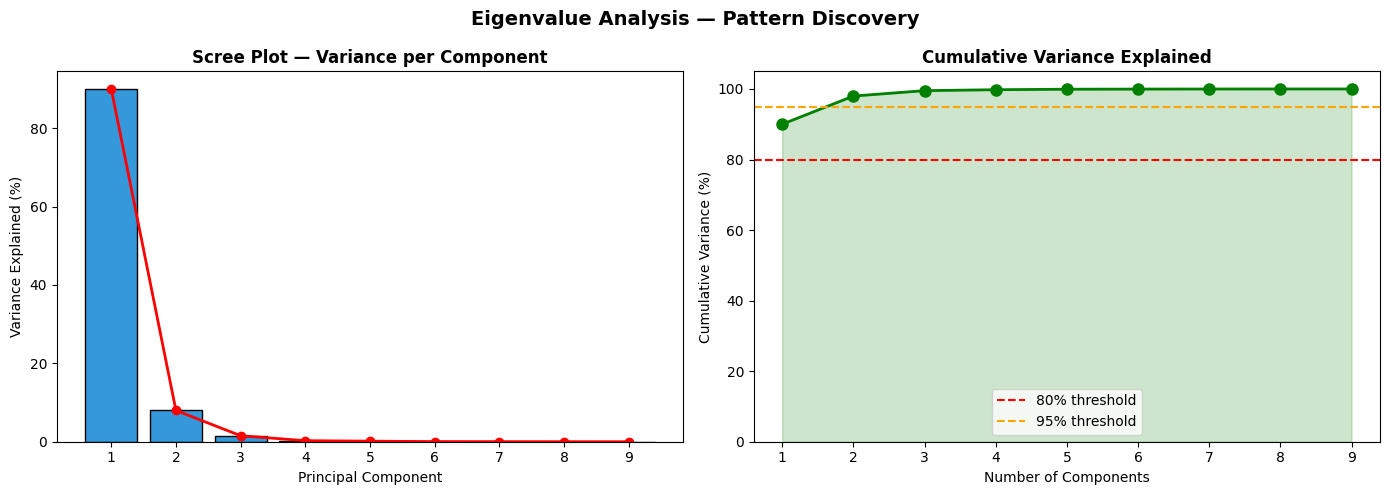

In [8]:
# --- Visualize Variance Explained (Scree Plot) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(eigenvalues)+1), variance_explained,
            color='#3498db', edgecolor='black')
axes[0].plot(range(1, len(eigenvalues)+1), variance_explained,
             'ro-', linewidth=2, markersize=6)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — Variance per Component',
                  fontweight='bold')
axes[0].set_xticks(range(1, len(eigenvalues)+1))

# Cumulative variance
axes[1].plot(range(1, len(eigenvalues)+1), cumulative_variance,
             'go-', linewidth=2, markersize=8)
axes[1].axhline(80, color='red', linestyle='--',
                linewidth=1.5, label='80% threshold')
axes[1].axhline(95, color='orange', linestyle='--',
                linewidth=1.5, label='95% threshold')
axes[1].fill_between(range(1, len(eigenvalues)+1),
                     cumulative_variance, alpha=0.2, color='green')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance Explained',
                  fontweight='bold')
axes[1].set_xticks(range(1, len(eigenvalues)+1))
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle('Eigenvalue Analysis — Pattern Discovery',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/step8_scree_plot.png', dpi=150)
plt.show()

In [9]:
# --- Step 4: Interpret Top Eigenvectors ---
# Each eigenvector is a "playing style direction"
# Large positive weights = stat strongly defines this style
# Large negative weights = stat inversely defines this style

n_components = min(3, len(eigenvalues))

print("=" * 50)
print("INTERPRETING TOP EIGENVECTORS (Playing Styles)")
print("=" * 50)

style_names = ['Dominant Batting Style',
               'Dominant Bowling Style',
               'All-Rounder Style']

for i in range(n_components):
    ev = eigenvectors[:, i]
    print(f"\nPC{i+1} — {style_names[i]}")
    print(f"  Variance explained : {variance_explained[i]:.2f}%")
    print(f"  Top contributors   :")
    top_feat_idx = np.argsort(np.abs(ev))[::-1][:3]
    for idx in top_feat_idx:
        direction = "↑ positive" if ev[idx] > 0 else "↓ negative"
        print(f"    {basis_features[idx]:<25}: "
              f"{ev[idx]:.4f} ({direction})")

INTERPRETING TOP EIGENVECTORS (Playing Styles)

PC1 — Dominant Batting Style
  Variance explained : 90.01%
  Top contributors   :
    Runs_Scored              : 0.9806 (↑ positive)
    Batting_Strike_Rate      : 0.1738 (↑ positive)
    Batting_Average          : 0.0752 (↑ positive)

PC2 — Dominant Bowling Style
  Variance explained : 7.98%
  Top contributors   :
    Batting_Strike_Rate      : -0.9804 (↓ negative)
    Runs_Scored              : 0.1806 (↑ positive)
    Batting_Average          : -0.0748 (↓ negative)

PC3 — All-Rounder Style
  Variance explained : 1.53%
  Top contributors   :
    Bowling_Average          : 0.9916 (↑ positive)
    Economy_Rate             : 0.0945 (↑ positive)
    Wickets_Taken            : 0.0536 (↑ positive)


In [10]:
# --- Step 5: Project Players onto Principal Components ---
# Each player gets a score on each principal component
# This reveals their "playing style fingerprint"

PC_scores = A_basis @ eigenvectors

print("=" * 50)
print("PLAYER SCORES ON PRINCIPAL COMPONENTS")
print("=" * 50)
print(f"PC Scores shape : {PC_scores.shape}")
print(f"\nTop 5 players on PC1 ({style_names[0]}):")
top_pc1 = np.argsort(PC_scores[:, 0])[::-1][:5]
for idx in top_pc1:
    print(f"  {player_names[idx]:<25} : {PC_scores[idx, 0]:.2f}")

print(f"\nTop 5 players on PC2 ({style_names[1]}):")
top_pc2 = np.argsort(PC_scores[:, 1])[::-1][:5]
for idx in top_pc2:
    print(f"  {player_names[idx]:<25} : {PC_scores[idx, 1]:.2f}")

PLAYER SCORES ON PRINCIPAL COMPONENTS
PC Scores shape : (1130, 9)

Top 5 players on PC1 (Dominant Batting Style):
  Virat Kohli               : 838.76
  Shubman Gill              : 756.91
  Jos Buttler               : 728.82
  David Warner              : 714.68
  Kane Williamson           : 601.74

Top 5 players on PC2 (Dominant Bowling Style):
  Virat Kohli               : 98.01
  Jos Buttler               : 82.69
  Ishant Sharma             : 80.76
  Harshal Patel             : 80.46
  Lockie Ferguson           : 79.46


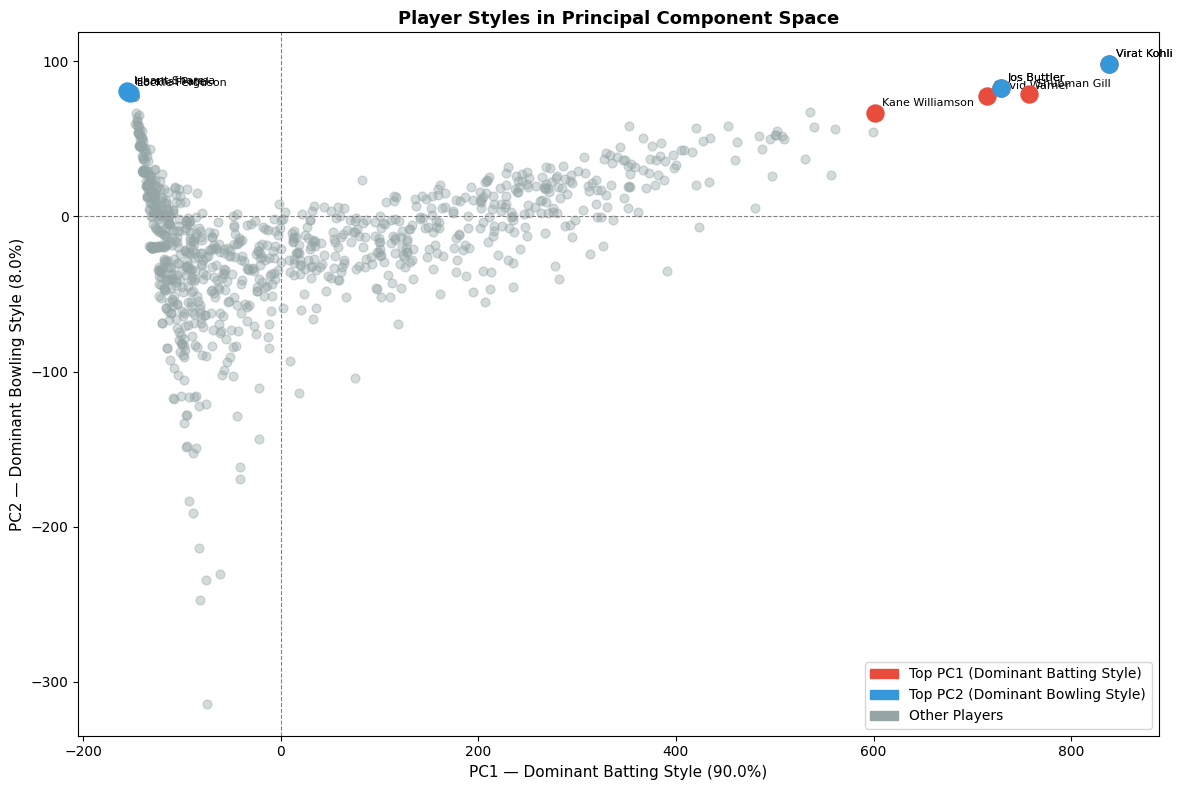

In [11]:
# --- Visualize Players in PC Space ---
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(PC_scores[:, 0], PC_scores[:, 1],
           alpha=0.4, color='#95a5a6', s=40)

# Highlight top players on PC1
for idx in top_pc1:
    ax.scatter(PC_scores[idx, 0], PC_scores[idx, 1],
               color='#e74c3c', s=150, zorder=5)
    ax.annotate(player_names[idx],
                (PC_scores[idx, 0], PC_scores[idx, 1]),
                fontsize=8, xytext=(5, 5),
                textcoords='offset points')

# Highlight top players on PC2
for idx in top_pc2:
    ax.scatter(PC_scores[idx, 0], PC_scores[idx, 1],
               color='#3498db', s=150, zorder=5)
    ax.annotate(player_names[idx],
                (PC_scores[idx, 0], PC_scores[idx, 1]),
                fontsize=8, xytext=(5, 5),
                textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel(f'PC1 — {style_names[0]} ({variance_explained[0]:.1f}%)',
              fontsize=11)
ax.set_ylabel(f'PC2 — {style_names[1]} ({variance_explained[1]:.1f}%)',
              fontsize=11)
ax.set_title('Player Styles in Principal Component Space',
             fontweight='bold', fontsize=13)

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label=f'Top PC1 ({style_names[0]})'),
          Patch(color='#3498db', label=f'Top PC2 ({style_names[1]})'),
          Patch(color='#95a5a6', label='Other Players')]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('../outputs/step8_pc_space.png', dpi=150)
plt.show()

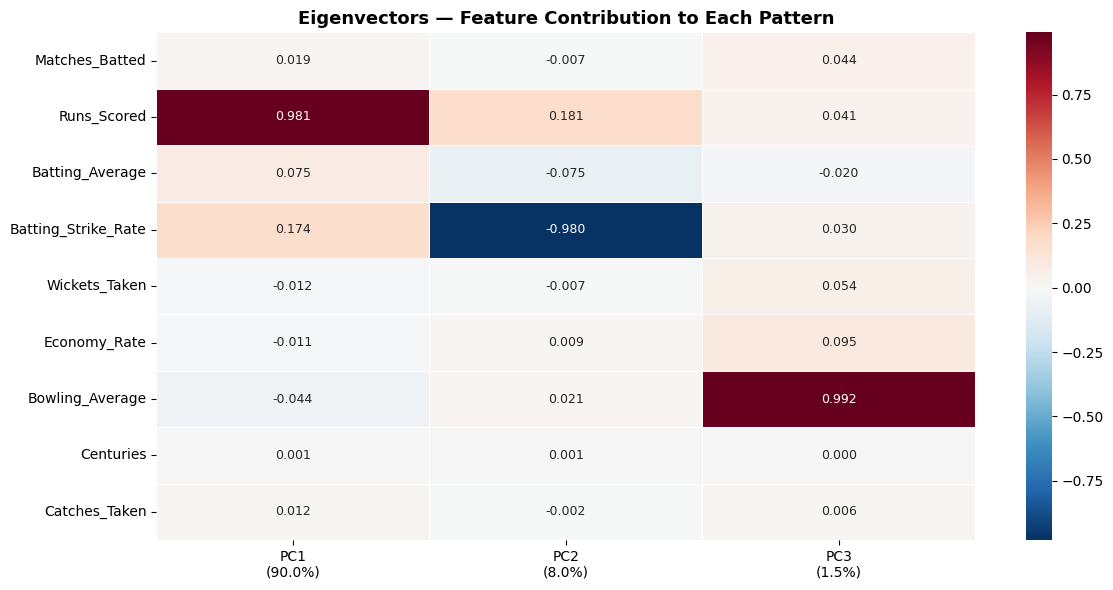

In [12]:
# --- Eigenvector Heatmap ---
fig, ax = plt.subplots(figsize=(12, 6))

df_ev = pd.DataFrame(
    eigenvectors[:, :n_components],
    index=basis_features,
    columns=[f'PC{i+1}\n({variance_explained[i]:.1f}%)'
             for i in range(n_components)]
)

sns.heatmap(df_ev, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Eigenvectors — Feature Contribution to Each Pattern',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/step8_eigenvectors.png', dpi=150)
plt.show()

In [13]:
# --- Summary ---
# How many components needed for 80% variance?
n_80 = np.argmax(cumulative_variance >= 80) + 1
n_95 = np.argmax(cumulative_variance >= 95) + 1

print("=" * 50)
print("STEP 8 SUMMARY — Pattern Discovery")
print("=" * 50)
print(f"""
Covariance Matrix Shape : {C.shape}
Total Variance          : {total_variance:.4f}

Eigenvalue Summary:
  Largest  λ1 = {eigenvalues[0]:.4f} ({variance_explained[0]:.2f}% variance)
  Smallest λn = {eigenvalues[-1]:.4f} ({variance_explained[-1]:.2f}% variance)

Components needed for:
  80% variance → {n_80} components
  95% variance → {n_95} components

Playing Styles Discovered:
  PC1 → {style_names[0]} ({variance_explained[0]:.1f}%)
  PC2 → {style_names[1]} ({variance_explained[1]:.1f}%)
  PC3 → {style_names[2]} ({variance_explained[2]:.1f}%)

Key Insight:
  We can represent players using just {n_80} components
  instead of {len(basis_features)} features while retaining
  80% of all performance information!
""")

# Save for Step 9
np.save('../data/eigenvalues.npy', eigenvalues)
np.save('../data/eigenvectors.npy', eigenvectors)
np.save('../data/PC_scores.npy', PC_scores)
np.save('../data/variance_explained.npy', variance_explained)
np.save('../data/cumulative_variance.npy', cumulative_variance)

print("✅ Step 8 Complete!")
print("   → Ready for Step 9: System Simplification")

STEP 8 SUMMARY — Pattern Discovery

Covariance Matrix Shape : (9, 9)
Total Variance          : 33707.8197

Eigenvalue Summary:
  Largest  λ1 = 30341.4893 (90.01% variance)
  Smallest λn = 0.0563 (0.00% variance)

Components needed for:
  80% variance → 1 components
  95% variance → 2 components

Playing Styles Discovered:
  PC1 → Dominant Batting Style (90.0%)
  PC2 → Dominant Bowling Style (8.0%)
  PC3 → All-Rounder Style (1.5%)

Key Insight:
  We can represent players using just 1 components
  instead of 9 features while retaining
  80% of all performance information!

✅ Step 8 Complete!
   → Ready for Step 9: System Simplification
